In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
from sklearn.exceptions import ConvergenceWarning, InconsistentVersionWarning
from sklearn.tree import DecisionTreeClassifier

import joblib
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix,
    balanced_accuracy_score, cohen_kappa_score
)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

In [2]:
TEST_DATA_DIR = '../data/splits/NearMiss_equal_test.csv'
test_df = pd.read_csv(TEST_DATA_DIR)

test_df.head(5)

,Elevation,Horizontal_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_Noon,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area3,Wilderness_Area4,Soil_Type2,Soil_Type4,...,Soil_Type12,Soil_Type22,Soil_Type23,Soil_Type38,Soil_Type39,Euclidean_Distance_To_Hydrology,Distance_To_Hydrology_To_Roadways_Ratio,Total_Distance,Aspect_North_South,Cover_Type
0,1.905040e+12,26.616358,17.027224,7.286826e+09,2446,1,0,0,0,0,...,0,0,0,0,0,26.894885,2.838889,38.860450,0.838671,1
1,2.467422e+12,16.576336,44.178571,5.878612e+09,362,0,1,0,0,0,...,0,0,0,0,0,16.999327,1.074519,34.703713,0.829038,0
2,1.214855e+12,7.970902,38.237365,6.986146e+09,335,0,0,1,0,0,...,0,0,0,0,0,8.294834,1.025510,30.800479,0.939693,5
3,1.381086e+12,29.238079,30.362725,1.242193e+10,541,0,0,1,0,0,...,0,0,0,0,0,30.076138,1.594118,31.394317,0.069756,2
4,9.734690e+11,26.348537,25.452623,9.876423e+09,1041,0,0,1,0,0,...,0,0,0,0,0,26.717475,1.720000,32.665238,0.258819,5


In [4]:
covertype_class = {
        1: 'Spruce/Fir', 2: 'Lodgepole Pine',
        3: 'Ponderosa Pine', 4: 'Cottonwood/Willow',
        5: 'Aspen', 6: 'Douglas-fir', 7:'Krummholz'
}

In [5]:
X_test = test_df.drop('Cover_Type', axis=1)
y_test = test_df['Cover_Type']

mapped_y = y_test.map(covertype_class)
print(mapped_y.value_counts())

Cover_Type
Cottonwood/Willow    550
Ponderosa Pine       550
Douglas-fir          550
Spruce/Fir           549
Aspen                549
Lodgepole Pine       549
Name: count, dtype: int64


# Model Comparison

- El modelo de bagging no tiene para el out of bag evaluation
- No estan subidos todos los Best Hyperparameters

In [6]:
def calculate_metrics(y_pred, y_test, model_name):
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "precision_micro": precision_score(y_test, y_pred, average="micro", zero_division=0),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_micro": recall_score(y_test, y_pred, average="micro", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(y_test, y_pred),
        "cohen_kappa": cohen_kappa_score(y_test, y_pred),
    }

    return metrics

### Random Forest

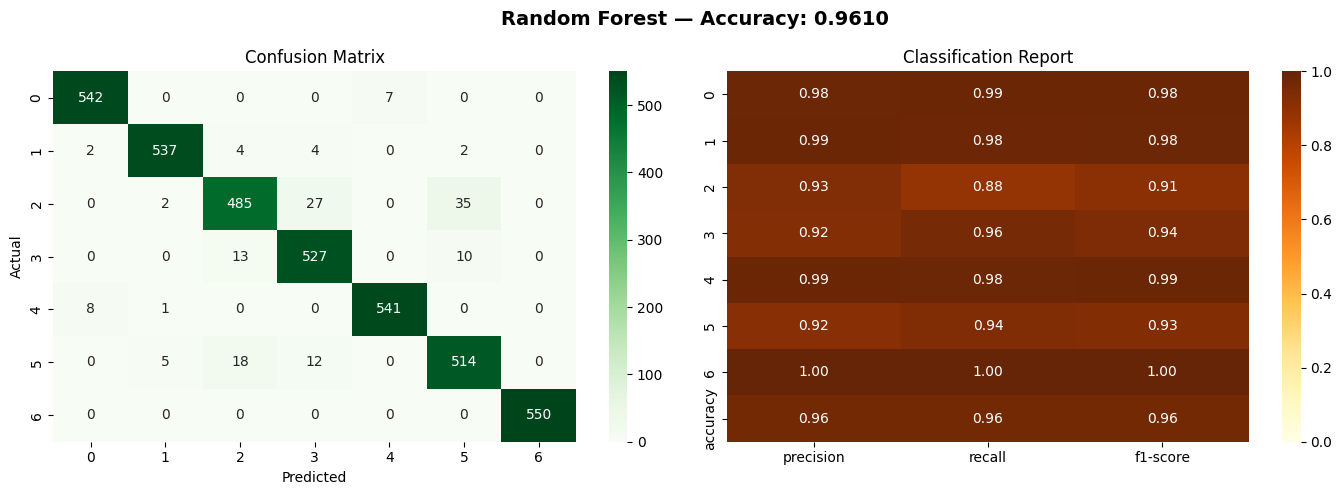

In [36]:
rf_clf = joblib.load('../models/RandomForest_NearMiss_equal_model.pkl')
y_pred = rf_clf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Random Forest — Accuracy: {accuracy_score(y_test, y_pred):.4f}', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_clf.classes_,
            yticklabels=rf_clf.classes_,
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Classification Report
import pandas as pd
report = classification_report(y_test, y_pred, target_names=[str(c) for c in rf_clf.classes_], output_dict=True)
report_df = pd.DataFrame(report).T.drop(columns='support').iloc[:-2]
sns.heatmap(report_df, annot=True, fmt='.2f', cmap='YlOrBr',
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Classification Report')

plt.tight_layout()
plt.show()

In [37]:
metrics_rf = calculate_metrics(y_pred, y_test, 'Random Forest')
metrics_rf = pd.DataFrame([metrics_rf]).T
metrics_rf.head(10)
metrics_rf.to_csv('../results/model_tests/rf_clf_results.csv')

### Voting Classifier - Hard Voting

Accuracy: 0.9342

Matriz de confusion:


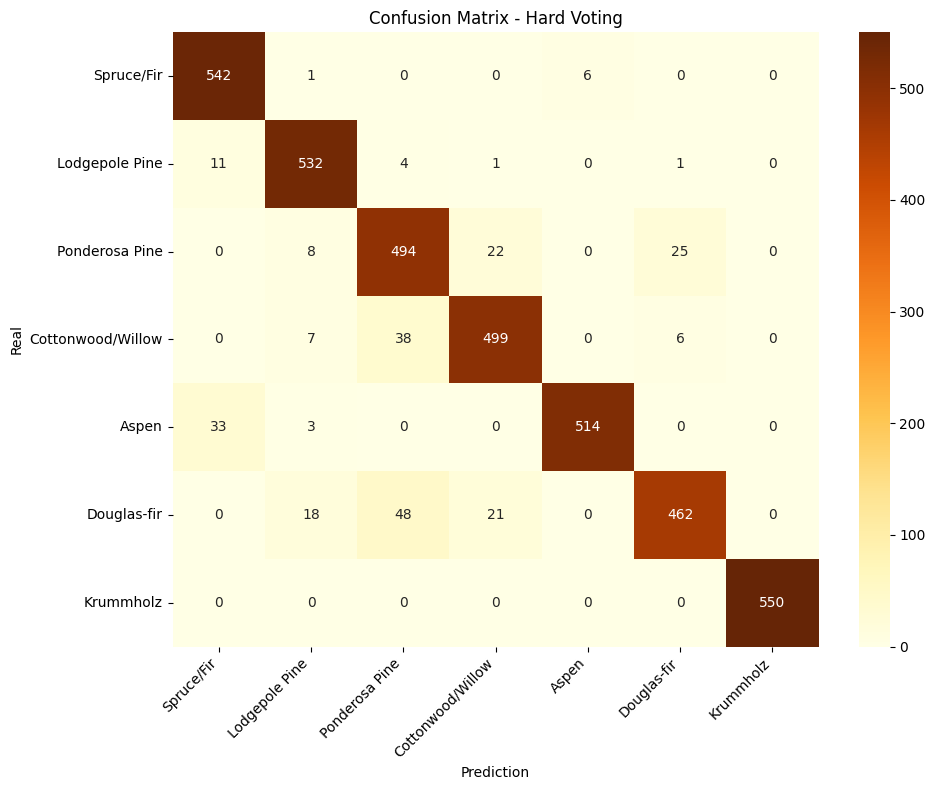

In [26]:
hv_model = joblib.load('../models/Hard-Voting-Clf_NearMiss_equal_model.pkl')
predictions = hv_model.predict(X_test)

y_labels = pd.Series(y_test).map(covertype_class)
pred_labels = pd.Series(predictions).map(covertype_class)

print('Accuracy:', round(accuracy_score(y_test, predictions), 4))

print('\nMatriz de confusion:')
classes = sorted(set(pd.Series(y_test).unique()) | set(pd.Series(predictions).unique()))
is_zero_based = min(classes) == 0 and max(classes) <= 6
label_keys = [int(c) + 1 if is_zero_based else int(c) for c in classes]
class_names = [covertype_class.get(k, str(k)) for k in label_keys]

cm = confusion_matrix(y_test, predictions, labels=classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confusion Matrix - Hard Voting')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
print('\nClassification report:')
print(classification_report(y_test, predictions))


Classification report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       549
           1       0.93      0.97      0.95       549
           2       0.85      0.90      0.87       549
           3       0.92      0.91      0.91       550
           4       0.99      0.93      0.96       550
           5       0.94      0.84      0.89       549
           6       1.00      1.00      1.00       550

    accuracy                           0.93      3846
   macro avg       0.94      0.93      0.93      3846
weighted avg       0.94      0.93      0.93      3846



In [27]:
metrics_hvc = calculate_metrics(predictions, y_test, 'Hard Voting Classifier')
metrics_hvc = pd.DataFrame([metrics_hvc]).T
metrics_hvc.head(10)
metrics_hvc.to_csv('../results/model_tests/hard_voting_clf.csv')

### Voting Classifier - Soft Voting

Accuracy: 0.9475

Matriz de confusion:


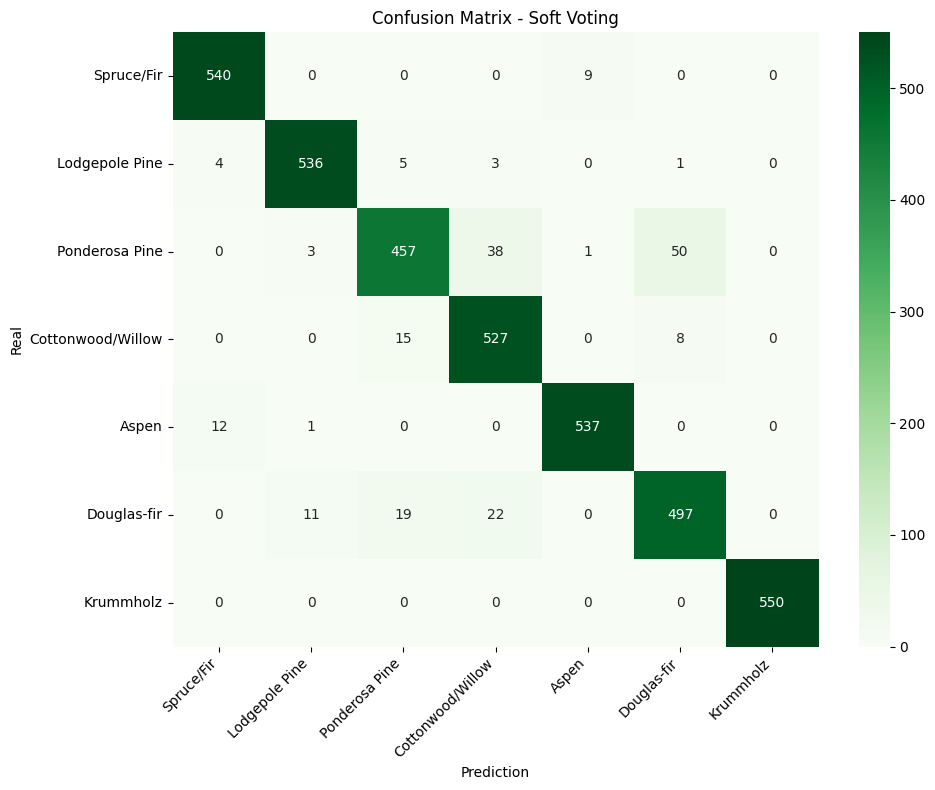

In [24]:
sv_model = joblib.load('../models/Soft-Voting-Clf_NearMiss_equal_model.pkl')
sv_predictions = sv_model.predict(X_test)

sv_pred_labels = pd.Series(sv_predictions).map(covertype_class)

print('Accuracy:', round(accuracy_score(y_test, sv_predictions), 4))

print('\nMatriz de confusion:')
classes = sorted(set(pd.Series(y_test).unique()) | set(pd.Series(sv_predictions).unique()))
is_zero_based = min(classes) == 0 and max(classes) <= 6
label_keys = [int(c) + 1 if is_zero_based else int(c) for c in classes]
class_names = [covertype_class.get(k, str(k)) for k in label_keys]

cm = confusion_matrix(y_test, sv_predictions, labels=classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confusion Matrix - Soft Voting')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [47]:
print('\nClassification report:')
print(classification_report(y_test, sv_predictions))


Classification report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       549
           1       0.97      0.98      0.97       549
           2       0.92      0.83      0.87       549
           3       0.89      0.96      0.92       550
           4       0.98      0.98      0.98       550
           5       0.89      0.91      0.90       549
           6       1.00      1.00      1.00       550

    accuracy                           0.95      3846
   macro avg       0.95      0.95      0.95      3846
weighted avg       0.95      0.95      0.95      3846



In [25]:
metrics_svc = calculate_metrics(sv_predictions, y_test, 'Soft Voting Classifier')
metrics_svc = pd.DataFrame([metrics_svc]).T
metrics_svc.head(10)
metrics_svc.to_csv('../results/model_tests/soft_voting_clf_results.csv')

### Bagging

Accuracy: 0.9607

Matriz de confusion:


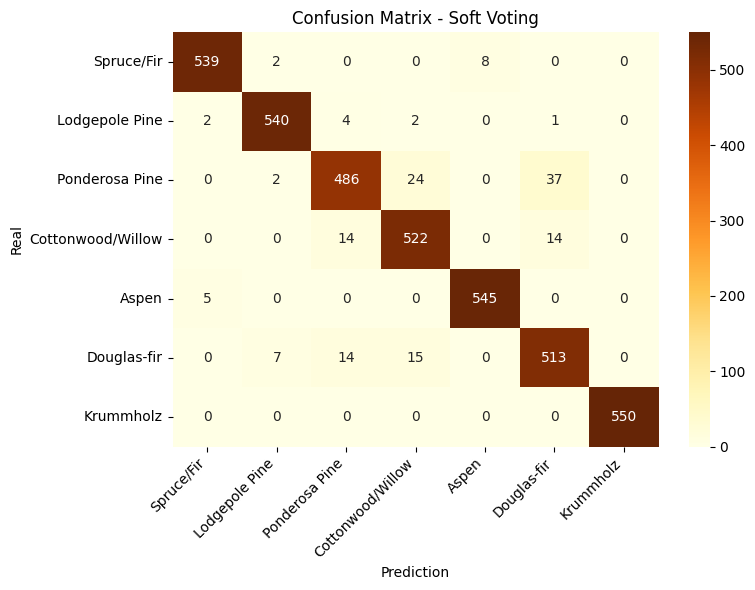

In [21]:
bagging_model = joblib.load('../models/BaggingClassifier_NearMiss_equal_model.pkl')
bagging_predictions = bagging_model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, bagging_predictions), 4))

print('\nMatriz de confusion:')
classes = sorted(set(pd.Series(y_test).unique()) | set(pd.Series(bagging_predictions).unique()))
is_zero_based = min(classes) == 0 and max(classes) <= 6
label_keys = [int(c) + 1 if is_zero_based else int(c) for c in classes]
class_names = [covertype_class.get(k, str(k)) for k in label_keys]

cm = confusion_matrix(y_test, bagging_predictions, labels=classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confusion Matrix - Soft Voting')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

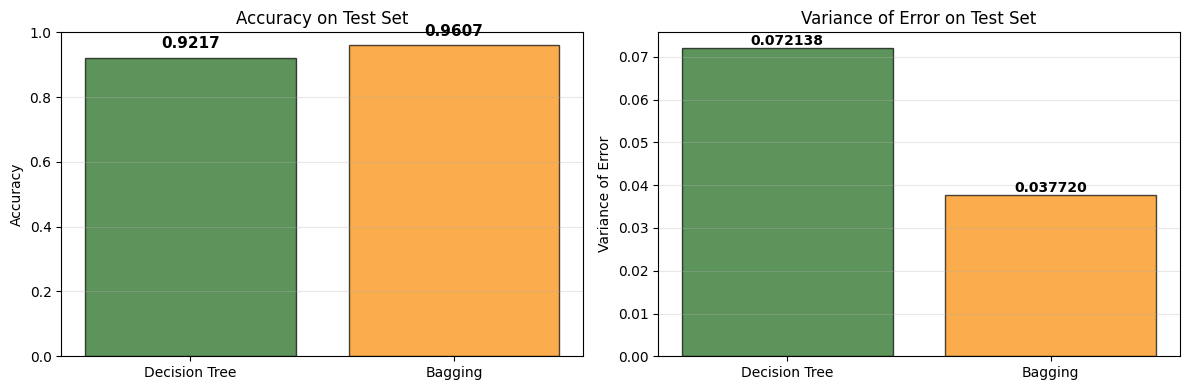

In [ ]:
train_df = pd.read_csv('../data/splits/NearMiss_equal_train.csv')
X_train = train_df.drop('Cover_Type', axis=1)
y_train = train_df['Cover_Type']


dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

dt_pred = dt_clf.predict(X_test)

dt_error_samples = (dt_pred != y_test).astype(int)
bagging_error_samples = (bagging_predictions != y_test).astype(int)

# Error variance
dt_error_var = np.var(dt_error_samples)
bagging_error_var = np.var(bagging_error_samples)

# Accuracy
dt_accuracy = round(accuracy_score(y_test, dt_pred), 4)
bagging_accuracy = round(accuracy_score(y_test, bagging_predictions), 4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy barplot
models = ['Decision Tree', 'Bagging']
accuracies = [dt_accuracy, bagging_accuracy]
colors = ["#196715", "#FA8900"]
bars = axes[0].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy on Test Set')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Variance barplot
variances = [dt_error_var, bagging_error_var]
bars = axes[1].bar(models, variances, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Variance of Error')
axes[1].set_title('Variance of Error on Test Set')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, var in zip(bars, variances):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{var:.6f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
metrics_bc = calculate_metrics(bagging_predictions, y_test, 'Bagging Classifier')
metrics_bc = pd.DataFrame([metrics_bc]).T
metrics_bc.head(10)
metrics_bc.to_csv('../results/model_tests/bagging_clf_results.csv')

## Boosting Models
### AdaBoost

Iterations: 200
Minimum error at iteration 155: 0.0387 (accuracy=0.9613)


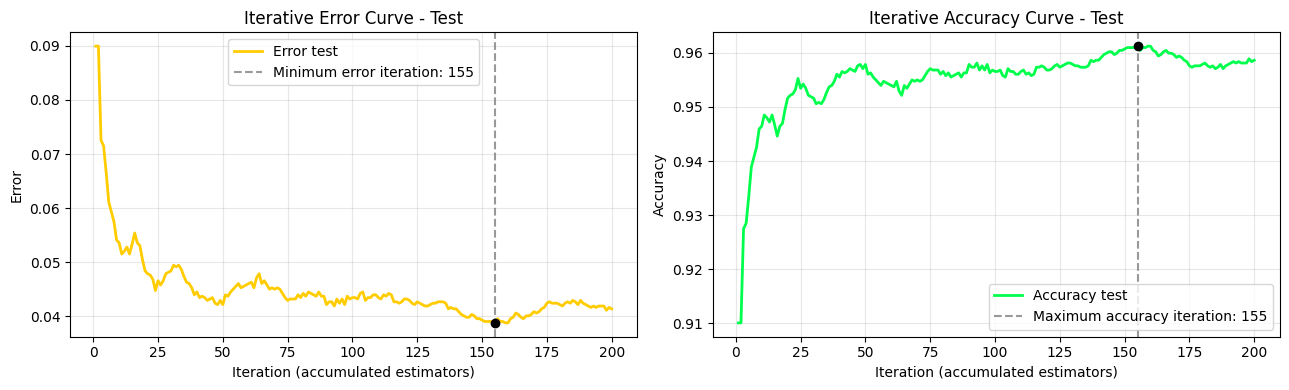

In [6]:
ada_model = joblib.load('../models/AdaBoost-RF_NearMiss_equal_model.pkl')


scaler = ada_model.named_steps.get('scaler', None)
ada_clf = ada_model.named_steps['clf']
X_for_staged = scaler.transform(X_test)

staged_errors = []
staged_accuracies = []

for y_pred_stage in ada_clf.staged_predict(X_for_staged):
    err = np.mean(y_pred_stage != y_test)
    staged_errors.append(err)
    staged_accuracies.append(1 - err)

iterations = np.arange(1, len(staged_errors) + 1)
best_iter = int(np.argmin(staged_errors))
best_error = staged_errors[best_iter]
best_acc = staged_accuracies[best_iter]

print(f'Iterations: {len(staged_errors)}')
print(f'Minimum error at iteration {best_iter + 1}: {best_error:.4f} (accuracy={best_acc:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(iterations, staged_errors, color="#FFCC00", lw=2, label='Error test')
axes[0].axvline(best_iter + 1, color='gray', linestyle='--', alpha=0.8,
                label=f'Minimum error iteration: {best_iter + 1}')
axes[0].scatter([best_iter + 1], [best_error], color='black', zorder=5)
axes[0].set_xlabel('Iteration (accumulated estimators)')
axes[0].set_ylabel('Error')
axes[0].set_title('Iterative Error Curve - Test')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(iterations, staged_accuracies, color="#00FF4C", lw=2, label='Accuracy test')
axes[1].axvline(best_iter + 1, color='gray', linestyle='--', alpha=0.8,
                label=f'Maximum accuracy iteration: {best_iter + 1}')
axes[1].scatter([best_iter + 1], [best_acc], color='black', zorder=5)
axes[1].set_xlabel('Iteration (accumulated estimators)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Iterative Accuracy Curve - Test')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
y_pred = ada_model.predict(X_test)

In [17]:
metrics_ada = calculate_metrics(y_pred, y_test, 'AdaBoost')
metrics_ada = pd.DataFrame([metrics_ada]).T
metrics_ada.head(12)
metrics_ada.to_csv('../results/model_tests/adaboost_clf_results.csv')

### XGBoost

Iterations: 300
Minimum error at iteration 179: 0.0320 (accuracy=0.9680)


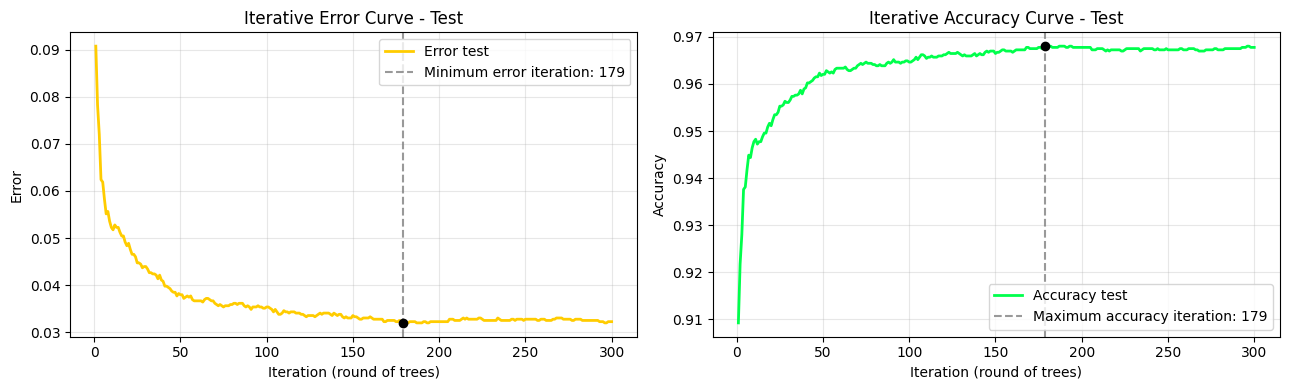

In [7]:
xgb_model = joblib.load('../models/xgboost_NearMiss_equal_model.pkl')

scaler = xgb_model.named_steps.get('scaler', None)
xgb_clf = xgb_model.named_steps['clf']
X_for_staged = scaler.transform(X_test) if scaler is not None else X_test

# Iterative evaluation by number of accumulated trees (iteration_range=(0, i))
n_rounds = xgb_clf.get_booster().num_boosted_rounds()

staged_errors = []
staged_accuracies = []

for i in range(1, n_rounds + 1):
    y_pred_stage = xgb_clf.predict(X_for_staged, iteration_range=(0, i))
    err = np.mean(y_pred_stage != y_test)
    staged_errors.append(err)
    staged_accuracies.append(1 - err)

iterations = np.arange(1, len(staged_errors) + 1)
best_iter = int(np.argmin(staged_errors))
best_error = staged_errors[best_iter]
best_acc = staged_accuracies[best_iter]

print(f'Iterations: {len(staged_errors)}')
print(f'Minimum error at iteration {best_iter + 1}: {best_error:.4f} (accuracy={best_acc:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(iterations, staged_errors, color="#FFCC00", lw=2, label='Error test')
axes[0].axvline(best_iter + 1, color='gray', linestyle='--', alpha=0.8,
                label=f'Minimum error iteration: {best_iter + 1}')
axes[0].scatter([best_iter + 1], [best_error], color='black', zorder=5)
axes[0].set_xlabel('Iteration (round of trees)')
axes[0].set_ylabel('Error')
axes[0].set_title('Iterative Error Curve - Test')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(iterations, staged_accuracies, color="#00FF4C", lw=2, label='Accuracy test')
axes[1].axvline(best_iter + 1, color='gray', linestyle='--', alpha=0.8,
                label=f'Maximum accuracy iteration: {best_iter + 1}')
axes[1].scatter([best_iter + 1], [best_acc], color='black', zorder=5)
axes[1].set_xlabel('Iteration (round of trees)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Iterative Accuracy Curve - Test')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
y_pred = xgb_model.predict(X_test)

In [9]:
metrics_xg = calculate_metrics(y_pred, y_test, 'XGBoost')
metrics_xg = pd.DataFrame([metrics_xg])
metrics_xg.T.head(12)
metrics_xg.T.to_csv('../results/model_tests/xgboost_clf_results.csv')

### Stacking

Accuracy: 0.9605


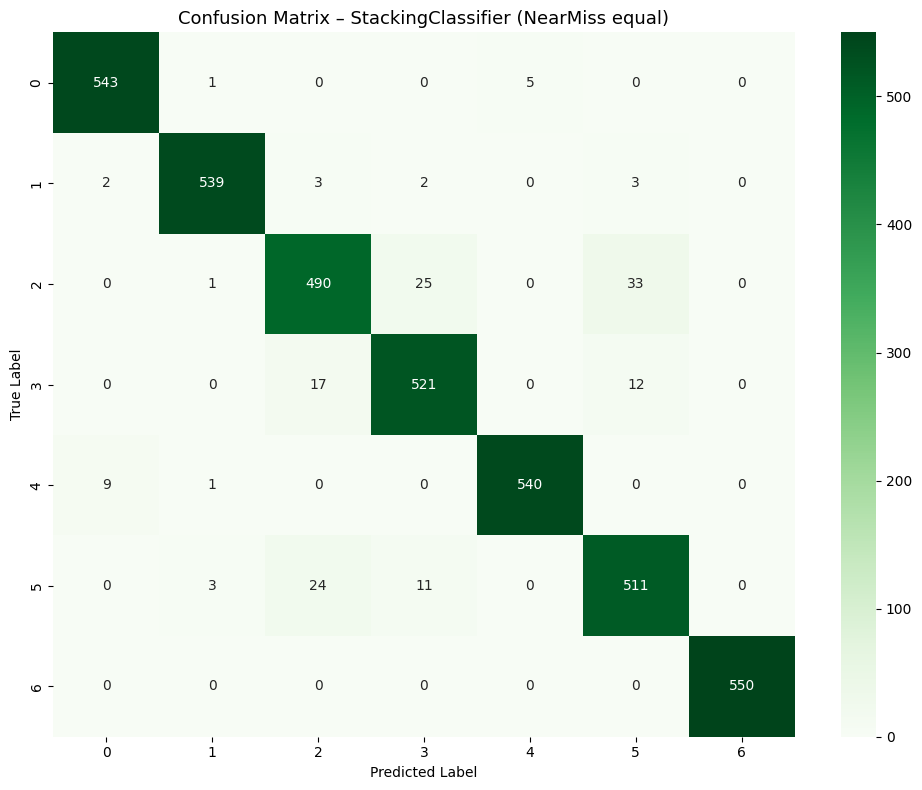

In [34]:
stacking_model = joblib.load('../models/StackingClassifier_NearMiss_equal_model.pkl')
y_pred = stacking_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap( cm, annot=True, fmt='d', cmap='Greens', xticklabels=stacking_model.classes_,
            yticklabels=stacking_model.classes_, ax=ax)
ax.set_title('Confusion Matrix – StackingClassifier (NearMiss equal)', fontsize=13)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

In [66]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       549
           1       0.99      0.98      0.99       549
           2       0.92      0.89      0.90       549
           3       0.93      0.95      0.94       550
           4       0.99      0.98      0.99       550
           5       0.91      0.93      0.92       549
           6       1.00      1.00      1.00       550

    accuracy                           0.96      3846
   macro avg       0.96      0.96      0.96      3846
weighted avg       0.96      0.96      0.96      3846



In [35]:
metrics_sc = calculate_metrics(y_pred, y_test, 'Stacking Classifier')
metrics_sc = pd.DataFrame([metrics_sc]).T
metrics_sc.head(12)
metrics_sc.to_csv('../results/model_tests/stacking_clf_results.csv')

## Model Comparison

In [ ]:
from pathlib import Path

In [4]:
metrics_files = {
    "Random Forest": "../results/model_tests/rf_clf_results.csv",
    "Hard Voting": "../results/model_tests/hard_voting_clf.csv",
    "Soft Voting": "../results/model_tests/soft_voting_clf_results.csv",
    "Bagging": "../results/model_tests/bagging_clf_results.csv",
    "AdaBoost": "../results/model_tests/adaboost_clf_results.csv",
    "XGBoost": "../results/model_tests/xgboost_clf_results.csv",
    "Stacking": "../results/model_tests/stacking_clf_results.csv",
}

In [ ]:
rows = []
for model_name, file_path in metrics_files.items():
    p = Path(file_path)
    if not p.exists():
        print(f"No existe: {file_path}")
        continue

    s = pd.read_csv(p, index_col=0).iloc[:, 0]
    s.name = model_name
    rows.append(s)

metrics_df = pd.DataFrame(rows)
metrics_df.index.name = "model"